In [9]:
import napari
from qtpy.QtWidgets import QSlider, QVBoxLayout, QWidget, QLabel
from qtpy.QtCore import Qt

import matplotlib.pyplot as plt
from skimage.feature import peak_local_max
from scipy.ndimage.interpolation import zoom
import numpy as np
import pandas as pd

import importlib
import sys
import os
cur=os.getcwd()
paths = [cur := os.path.dirname(cur) for _ in range(3)]
sys.path.insert(0, paths[0])

from Helpers import loadData, saveData
importlib.reload(sys.modules['Helpers.loadData'])
importlib.reload(sys.modules['Helpers'])

C:\Users\Lab User\AppData\Local\Temp\ipykernel_18732\2649585243.py:7: DeprecationWarning: Please import `zoom` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import zoom


<module 'Helpers' from 'd:\\temp1\\Granular-Compression\\Identification\\Helpers\\__init__.py'>

In [10]:
# Load convolution and raw data
cycl = 'Cycle4s3'
conv = loadData(os.path.join(paths[1],'Data'), f'f{cycl}Conv.hdf5')
data = loadData(os.path.join(paths[1],'Data'), f'f{cycl}Raw.hdf5')

In [11]:
# Find peaks from conv
peaks = peak_local_max(conv,min_distance=30) 

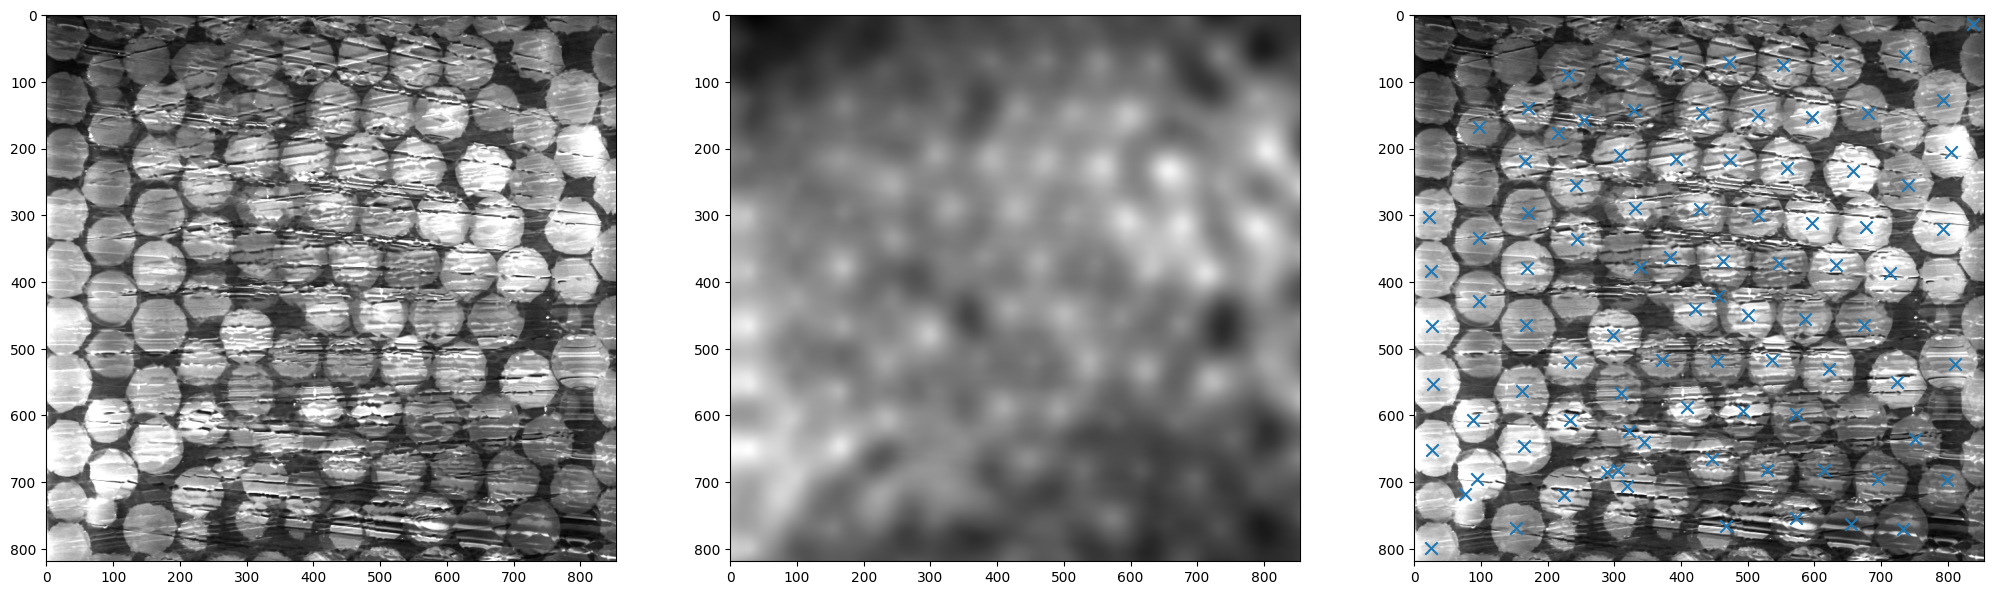

In [12]:
p=170
img = data[:,:,p]
cimg= conv[:,:,p]
peak = peak_local_max(cimg,min_distance=7) 

fig,axs = plt.subplots(1,3)

axs[0].imshow(img[:,:],cmap='grey')
axs[1].imshow(cimg[:,:],cmap='grey')
axs[2].imshow(img[:,:],cmap='grey'); axs[2].scatter(peak[:,1], peak[:,0], s=80, marker='x')

fig.set_size_inches(25,15)

In [13]:
volume = np.copy(zoom(data, 0.25))
center = np.copy(peaks*0.25)

In [14]:
viewer = napari.Viewer(ndisplay=3)
image_layer = viewer.add_image(volume, name='Volume', colormap='gray') # Plots in [z,y,x]
points_layer = viewer.add_points(center, size=3, face_color='red', name='Centers')

dock_widget = QWidget() # Visualize
layout = QVBoxLayout()

label_min = QLabel("Min Z")
slider_min = QSlider(Qt.Horizontal)
slider_min.setMinimum(0)
slider_min.setMaximum(volume.shape[0]-1) # Uses z coord of data -1 to find max
slider_min.setValue(0)

label_max = QLabel("Max Z")
slider_max = QSlider(Qt.Horizontal)
slider_max.setMinimum(0)
slider_max.setMaximum(volume.shape[0]-1)
slider_max.setValue(volume.shape[0]-1)

layout.addWidget(label_min)
layout.addWidget(slider_min)
layout.addWidget(label_max)
layout.addWidget(slider_max)
dock_widget.setLayout(layout)
viewer.window.add_dock_widget(dock_widget, area='right')

def update_view():
    
    zmin = slider_min.value()
    zmax = slider_max.value()

    # Clip points to slab
    filtered_points = center[(center[:, 0] >= zmin) & (center[:, 0] <= zmax)]
    points_layer.data = filtered_points  # z, y, x order

    # Clip volume to slab
    filtered_data = volume[zmin:zmax+1, :, :]
    image_layer.data = np.pad(filtered_data, pad_width=[[zmin, volume.shape[0] - zmax - 1], [0, 0], [0, 0]], mode='constant', constant_values=0)

slider_min.valueChanged.connect(update_view)
slider_max.valueChanged.connect(update_view)
update_view()  # initialize

napari.run()

In [16]:
exp = 17
procDir = os.path.join(paths[1], 'DataProcessed')
saveDir = procDir+r'/'+str(exp); os.mkdir(saveDir)

peaksDf = pd.DataFrame(peaks, columns=['z', 'y', 'x'])  # adjust labels to match your axes
peaksDf.to_csv(os.path.join(saveDir, f'{cycl}Peaks.csv'), index=False)

saveData(data=data,location=saveDir,saveName=cycl)